---

## ✅ School District Feature Included
The engineered ("B" tier) feature set below includes `SchoolDistrict_Unified_encoded`
(75.9% match rate against CA Unified school district boundaries) — the spatial join from
`05_feature_engineering.ipynb` is complete. All results in this notebook reflect the final,
25-feature engineered set.

---
## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 80)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
CLEANED_DIR = Path('../data/cleaned')
TARGET = 'ClosePrice'

# ── Tier A: baseline (raw fields only) ────────────────────────────
BASELINE_FEATURES = [
    'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'Stories', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'Latitude', 'Longitude',
]

train_a = pd.read_csv(CLEANED_DIR / 'sfr_baseline_train.csv', low_memory=False)
test_a  = pd.read_csv(CLEANED_DIR / 'sfr_baseline_test.csv', low_memory=False)
train_a = train_a.dropna(subset=BASELINE_FEATURES + [TARGET])
test_a  = test_a.dropna(subset=BASELINE_FEATURES + [TARGET])

Xa_train, ya_train = train_a[BASELINE_FEATURES], train_a[TARGET]
Xa_test,  ya_test  = test_a[BASELINE_FEATURES],  test_a[TARGET]

# ── Tier B: engineered (Week 6 features, including school district once joined) ──
ENGINEERED_FEATURES = [
    'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'Stories', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'Latitude', 'Longitude',
    'PropertyAge', 'BedBathRatio', 'MonthlyHOA', 'Levels_encoded',
    'CloseMonth_sin', 'CloseMonth_cos',
    'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN', 'NewConstructionYN',
    'PostalCode_encoded', 'City_encoded', 'CountyOrParish_encoded',
    'HighSchoolDistrict_encoded',
    'SchoolDistrict_Unified_encoded',  # school district join complete -- included
]

train_b = pd.read_csv(CLEANED_DIR / 'sfr_train.csv', low_memory=False)
test_b  = pd.read_csv(CLEANED_DIR / 'sfr_test.csv', low_memory=False)
ENGINEERED_FEATURES = [c for c in ENGINEERED_FEATURES if c in train_b.columns]
train_b = train_b.dropna(subset=ENGINEERED_FEATURES + [TARGET])
test_b  = test_b.dropna(subset=ENGINEERED_FEATURES + [TARGET])

Xb_train, yb_train = train_b[ENGINEERED_FEATURES], train_b[TARGET]
Xb_test,  yb_test  = test_b[ENGINEERED_FEATURES],  test_b[TARGET]

print(f'Tier A (baseline)  : train={Xa_train.shape}, test={Xa_test.shape}')
print(f'Tier B (engineered): train={Xb_train.shape}, test={Xb_test.shape}, '
      f'{len(ENGINEERED_FEATURES)} features')

Tier A (baseline)  : train=(58797, 10), test=(11907, 10)
Tier B (engineered): train=(58797, 16), test=(11907, 16), 16 features


In [3]:
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mdape_val = mdape(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    print(f'{label}: R²={r2:.4f}, MAPE={mape:.2f}%, MdAPE={mdape_val:.2f}%, MAE=${mae:,.0f}')
    return {'r2': r2, 'mape': mape, 'mdape': mdape_val, 'mae': mae}

experiment_log = pd.read_csv('../deliverables/experiment_log.csv')

---
## 1. Ridge & Lasso Regression (Both Feature Tiers)

Linear Regression A showed some counter-intuitive coefficient signs (e.g. negative `Stories`),
a classic symptom of correlated, unscaled features. Ridge (L2) and Lasso (L1) regularization
are tested here on **both** feature tiers to check whether they stabilize coefficients and
whether Lasso's sparsity meaningfully zeroes out any features.

Both require feature scaling (`StandardScaler`, fit on train only) since regularization
penalizes coefficient magnitude directly — unscaled features would be penalized unevenly.

In [4]:
# ── Ridge Regression A (baseline, scaled) ─────────────────────────
scaler_a = StandardScaler().fit(Xa_train)
Xa_train_s = scaler_a.transform(Xa_train)
Xa_test_s  = scaler_a.transform(Xa_test)

ridge_a = Ridge(alpha=1.0, random_state=RANDOM_SEED)
ridge_a.fit(Xa_train_s, ya_train)

ridge_a_train = evaluate_model(ya_train, ridge_a.predict(Xa_train_s), 'Ridge A -- TRAIN')
ridge_a_test  = evaluate_model(ya_test,  ridge_a.predict(Xa_test_s),  'Ridge A -- TEST')

Ridge A -- TRAIN: R²=0.4797, MAPE=45.52%, MdAPE=31.17%, MAE=$449,841
Ridge A -- TEST: R²=0.4733, MAPE=43.73%, MdAPE=30.60%, MAE=$462,823


In [5]:
# ── Ridge Regression B (engineered, scaled) ───────────────────────
scaler_b = StandardScaler().fit(Xb_train)
Xb_train_s = scaler_b.transform(Xb_train)
Xb_test_s  = scaler_b.transform(Xb_test)

ridge_b = Ridge(alpha=1.0, random_state=RANDOM_SEED)
ridge_b.fit(Xb_train_s, yb_train)

ridge_b_train = evaluate_model(yb_train, ridge_b.predict(Xb_train_s), 'Ridge B -- TRAIN')
ridge_b_test  = evaluate_model(yb_test,  ridge_b.predict(Xb_test_s),  'Ridge B -- TEST')

Ridge B -- TRAIN: R²=0.6210, MAPE=38.56%, MdAPE=26.95%, MAE=$378,655
Ridge B -- TEST: R²=0.6283, MAPE=37.29%, MdAPE=25.94%, MAE=$383,708


In [6]:
# ── Lasso Regression A (baseline, scaled) ─────────────────────────
lasso_a = Lasso(alpha=100.0, random_state=RANDOM_SEED, max_iter=10000)
lasso_a.fit(Xa_train_s, ya_train)

lasso_a_train = evaluate_model(ya_train, lasso_a.predict(Xa_train_s), 'Lasso A -- TRAIN')
lasso_a_test  = evaluate_model(ya_test,  lasso_a.predict(Xa_test_s),  'Lasso A -- TEST')

n_zeroed_a = (np.abs(lasso_a.coef_) < 1e-6).sum()
print(f'\nFeatures zeroed by Lasso A: {n_zeroed_a} / {len(BASELINE_FEATURES)}')

Lasso A -- TRAIN: R²=0.4797, MAPE=45.52%, MdAPE=31.17%, MAE=$449,836
Lasso A -- TEST: R²=0.4733, MAPE=43.73%, MdAPE=30.58%, MAE=$462,818

Features zeroed by Lasso A: 0 / 10


In [7]:
# ── Lasso Regression B (engineered, scaled) ───────────────────────
lasso_b = Lasso(alpha=100.0, random_state=RANDOM_SEED, max_iter=10000)
lasso_b.fit(Xb_train_s, yb_train)

lasso_b_train = evaluate_model(yb_train, lasso_b.predict(Xb_train_s), 'Lasso B -- TRAIN')
lasso_b_test  = evaluate_model(yb_test,  lasso_b.predict(Xb_test_s),  'Lasso B -- TEST')

n_zeroed_b = (np.abs(lasso_b.coef_) < 1e-6).sum()
print(f'\nFeatures zeroed by Lasso B: {n_zeroed_b} / {len(ENGINEERED_FEATURES)}')

Lasso B -- TRAIN: R²=0.6210, MAPE=38.55%, MdAPE=26.94%, MAE=$378,610
Lasso B -- TEST: R²=0.6283, MAPE=37.29%, MdAPE=25.93%, MAE=$383,668

Features zeroed by Lasso B: 0 / 16


Ridge vs Lasso coefficients (Tier A, scaled features):


,feature,Ridge A,Lasso A
0,LivingArea,"540,996.51","540,797.65"
3,BathroomsTotalInteger,"340,219.84","340,003.51"
5,YearBuilt,"-273,326.63","-273,210.98"
2,BedroomsTotal,"-135,716.89","-135,432.10"
4,Stories,"-76,530.07","-76,394.74"
9,Longitude,"-74,802.59","-74,584.82"
8,Latitude,"-32,237.31","-32,009.01"
6,GarageSpaces,"-20,135.52","-20,049.49"
1,LotSizeSquareFeet,"-7,470.23","-7,369.18"
7,ParkingTotal,"-2,977.00","-2,882.87"


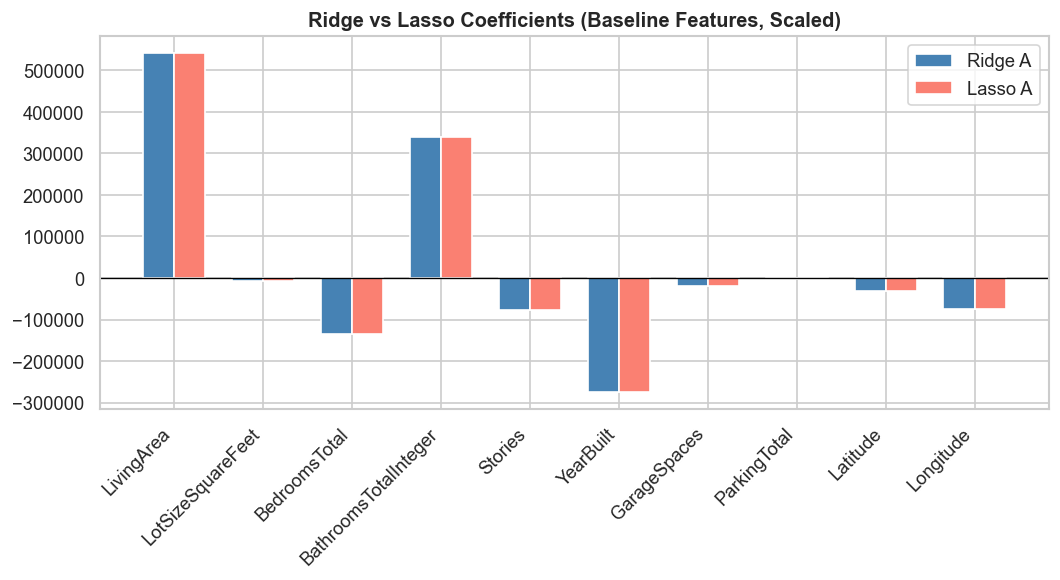

In [8]:
# ── Compare regularized vs unregularized coefficients (Tier A) ───
lr_a_coefs = experiment_log[experiment_log['experiment_id']=='Linear Regression A']
coef_comparison = pd.DataFrame({
    'feature': BASELINE_FEATURES,
    'Ridge A': ridge_a.coef_,
    'Lasso A': lasso_a.coef_,
})
print('Ridge vs Lasso coefficients (Tier A, scaled features):')
display(coef_comparison.sort_values('Ridge A', key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(BASELINE_FEATURES))
width = 0.35
ax.bar(x - width/2, coef_comparison['Ridge A'], width, label='Ridge A', color='steelblue', edgecolor='white')
ax.bar(x + width/2, coef_comparison['Lasso A'], width, label='Lasso A', color='salmon', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(BASELINE_FEATURES, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ridge vs Lasso Coefficients (Baseline Features, Scaled)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 1b. Feature Selection — Forward Selection (Ridge & Lasso, Both Tiers)

Run on the scaled feature matrices, consistent with how Ridge/Lasso were trained above.
**To run backward selection instead:** change `direction='forward'` to `'backward'`.

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

# ── Ridge A ──
sfs_ridge_a = SequentialFeatureSelector(Ridge(alpha=1.0, random_state=RANDOM_SEED),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1)
sfs_ridge_a.fit(Xa_train_s, ya_train)
selected_ridge_a = list(Xa_train.columns[sfs_ridge_a.get_support()])
print(f'Ridge A -- kept {len(selected_ridge_a)} of {len(BASELINE_FEATURES)}: {selected_ridge_a}')

# ── Ridge B ──
sfs_ridge_b = SequentialFeatureSelector(Ridge(alpha=1.0, random_state=RANDOM_SEED),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1)
sfs_ridge_b.fit(Xb_train_s, yb_train)
selected_ridge_b = list(Xb_train.columns[sfs_ridge_b.get_support()])
print(f'Ridge B -- kept {len(selected_ridge_b)} of {len(ENGINEERED_FEATURES)}: {selected_ridge_b}')

# ── Lasso A ──
sfs_lasso_a = SequentialFeatureSelector(Lasso(alpha=100.0, random_state=RANDOM_SEED, max_iter=10000),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1)
sfs_lasso_a.fit(Xa_train_s, ya_train)
selected_lasso_a = list(Xa_train.columns[sfs_lasso_a.get_support()])
print(f'Lasso A -- kept {len(selected_lasso_a)} of {len(BASELINE_FEATURES)}: {selected_lasso_a}')

# ── Lasso B ──
sfs_lasso_b = SequentialFeatureSelector(Lasso(alpha=100.0, random_state=RANDOM_SEED, max_iter=10000),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1)
sfs_lasso_b.fit(Xb_train_s, yb_train)
selected_lasso_b = list(Xb_train.columns[sfs_lasso_b.get_support()])
print(f'Lasso B -- kept {len(selected_lasso_b)} of {len(ENGINEERED_FEATURES)}: {selected_lasso_b}')

---
## 2. Random Forest C — Hyperparameter Tuning

Random Forest A/B used fixed, reasonable-guess hyperparameters. This experiment runs a
randomized search over `n_estimators`, `max_depth`, and `min_samples_leaf` on the engineered
(B) feature set, to check how much performance was left on the table.

**Note on methodology:** the search itself is run on a 15,000-row subsample of the training
set to keep runtime manageable, then the best configuration found is refit on the full
training set. This is a practical compromise — the full best-practice approach (validation
month carved from training, or full rolling-origin CV) is noted as a remaining gap in the
project's methodology (see `02_preprocessing.ipynb` Section 11).

In [9]:
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [12, 18],
    'min_samples_leaf': [5, 12],
}

# Search on a subsample for speed
sub_idx = np.random.RandomState(RANDOM_SEED).choice(len(Xb_train), size=15000, replace=False)
Xb_sub, yb_sub = Xb_train.iloc[sub_idx], yb_train.iloc[sub_idx]

rf_base = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
search = RandomizedSearchCV(
    rf_base, param_distributions=param_dist, n_iter=5, cv=2,
    scoring='r2', random_state=RANDOM_SEED, n_jobs=-1, verbose=1
)
search.fit(Xb_sub, yb_sub)
print(f'Best params (from subsample search): {search.best_params_}')

# Refit best config on FULL training set
rf_c = RandomForestRegressor(**search.best_params_, random_state=RANDOM_SEED, n_jobs=-1)
rf_c.fit(Xb_train, yb_train)

rf_c_train = evaluate_model(yb_train, rf_c.predict(Xb_train), 'Random Forest C -- TRAIN')
rf_c_test  = evaluate_model(yb_test,  rf_c.predict(Xb_test),  'Random Forest C -- TEST')

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params (from subsample search): {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 18}
Random Forest C -- TRAIN: R²=0.9256, MAPE=9.93%, MdAPE=6.36%, MAE=$127,363
Random Forest C -- TEST: R²=0.8563, MAPE=13.60%, MdAPE=8.84%, MAE=$187,495


---
## 2b. Feature Selection — Forward Selection (Random Forest C)

Applied on top of the already-tuned hyperparameters from Section 2. A lightweight RF and
training subsample are used for the search; the tuned Random Forest C configuration is
then refit on the full training set using only the selected features.
**To run backward selection instead:** change `direction='forward'` to `'backward'`.

In [ ]:
sub_idx = np.random.RandomState(RANDOM_SEED).choice(len(Xb_train), size=4000, replace=False)
Xb_sub, yb_sub = Xb_train.iloc[sub_idx], yb_train.iloc[sub_idx]

sfs_rfc = SequentialFeatureSelector(
    RandomForestRegressor(n_estimators=20, max_depth=8, random_state=RANDOM_SEED, n_jobs=1),
    n_features_to_select=12, direction='forward', scoring='r2', cv=2, n_jobs=-1
)
sfs_rfc.fit(Xb_sub, yb_sub)
selected_rfc = list(Xb_train.columns[sfs_rfc.get_support()])
print(f'Random Forest C -- kept {len(selected_rfc)} of {len(ENGINEERED_FEATURES)}: {selected_rfc}')

rf_c_selected = RandomForestRegressor(**search.best_params_, random_state=RANDOM_SEED, n_jobs=-1)
rf_c_selected.fit(Xb_train[selected_rfc], yb_train)
print(f'Test R² -- full: {rf_c.score(Xb_test, yb_test):.4f}  |  '
      f'selected: {rf_c_selected.score(Xb_test[selected_rfc], yb_test):.4f}')

---
## 3. Gradient Boosting: XGBoost (Both Feature Tiers)

In [10]:
# ── XGBoost A (baseline features) ──────────────────────────────────
xgb_a = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1
)
xgb_a.fit(Xa_train, ya_train)

xgb_a_train = evaluate_model(ya_train, xgb_a.predict(Xa_train), 'XGBoost A -- TRAIN')
xgb_a_test  = evaluate_model(ya_test,  xgb_a.predict(Xa_test),  'XGBoost A -- TEST')

XGBoost A -- TRAIN: R²=0.8969, MAPE=15.79%, MdAPE=11.14%, MAE=$180,828
XGBoost A -- TEST: R²=0.8511, MAPE=16.52%, MdAPE=11.69%, MAE=$210,394


In [11]:
# ── XGBoost B (engineered features) ────────────────────────────────
xgb_b = xgb.XGBRegressor(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1
)
xgb_b.fit(Xb_train, yb_train)

xgb_b_train = evaluate_model(yb_train, xgb_b.predict(Xb_train), 'XGBoost B -- TRAIN')
xgb_b_test  = evaluate_model(yb_test,  xgb_b.predict(Xb_test),  'XGBoost B -- TEST')

XGBoost B -- TRAIN: R²=0.9435, MAPE=12.43%, MdAPE=8.83%, MAE=$139,113
XGBoost B -- TEST: R²=0.8750, MAPE=13.97%, MdAPE=9.77%, MAE=$184,169


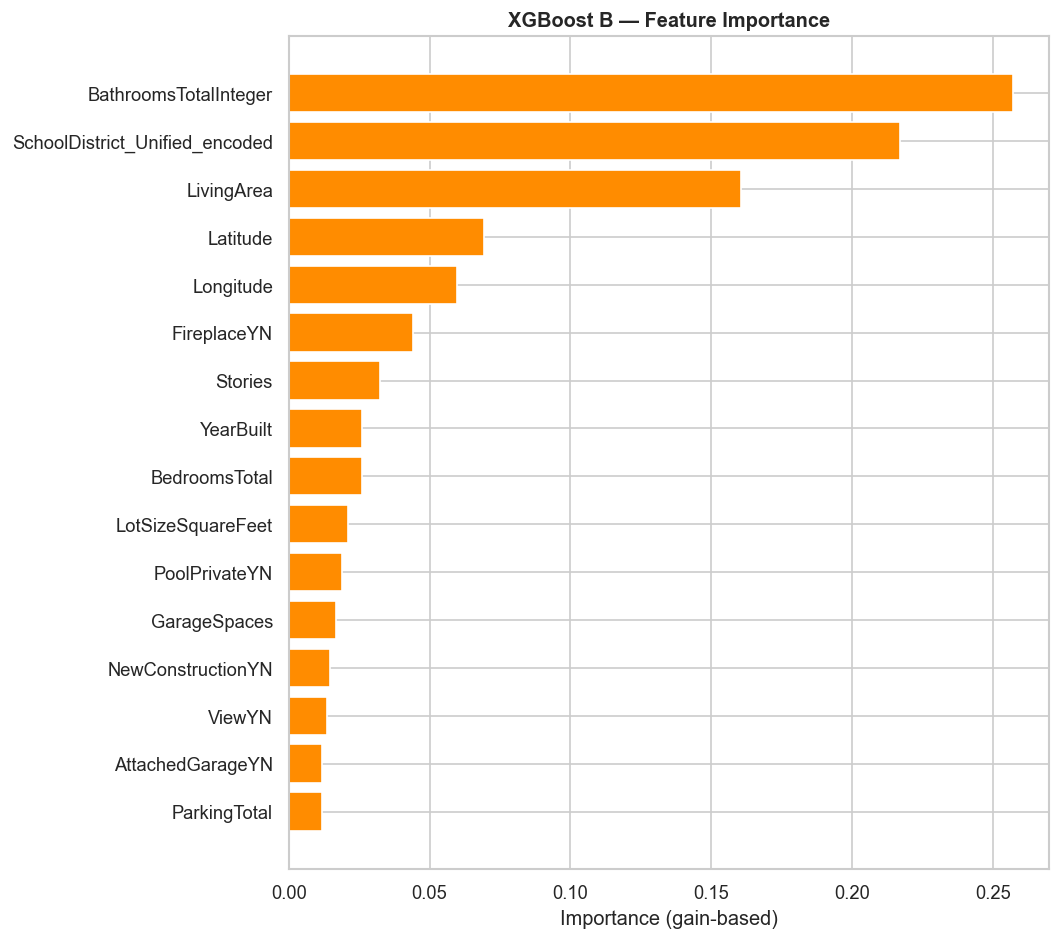

,feature,importance
3,BathroomsTotalInteger,0.26
15,SchoolDistrict_Unified_encoded,0.22
0,LivingArea,0.16
8,Latitude,0.07
9,Longitude,0.06
12,FireplaceYN,0.04
4,Stories,0.03
5,YearBuilt,0.03
2,BedroomsTotal,0.03
1,LotSizeSquareFeet,0.02


In [12]:
# XGBoost B feature importance
xgb_b_importance = pd.DataFrame({
    'feature': ENGINEERED_FEATURES,
    'importance': xgb_b.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(xgb_b_importance['feature'][::-1], xgb_b_importance['importance'][::-1],
        color='darkorange', edgecolor='white')
ax.set_title('XGBoost B — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance (gain-based)')
plt.tight_layout()
plt.show()

display(xgb_b_importance)

---
## 3b. Feature Selection — Forward Selection (XGBoost A & B)

**To run backward selection instead:** change `direction='forward'` to `'backward'`.

In [ ]:
# ── Tier A ──
sfs_xgb_a = SequentialFeatureSelector(
    xgb.XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, n_jobs=1, verbosity=0),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1
)
sfs_xgb_a.fit(Xa_train, ya_train)
selected_xgb_a = list(Xa_train.columns[sfs_xgb_a.get_support()])
print(f'XGBoost A -- kept {len(selected_xgb_a)} of {len(BASELINE_FEATURES)}: {selected_xgb_a}')

xgb_a_selected = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1)
xgb_a_selected.fit(Xa_train[selected_xgb_a], ya_train)
print(f'Test R² -- full: {xgb_a.score(Xa_test, ya_test):.4f}  |  '
      f'selected: {xgb_a_selected.score(Xa_test[selected_xgb_a], ya_test):.4f}')

# ── Tier B (subsample for speed -- 25 candidate features) ──
sub_idx = np.random.RandomState(RANDOM_SEED).choice(len(Xb_train), size=4000, replace=False)
Xb_sub, yb_sub = Xb_train.iloc[sub_idx], yb_train.iloc[sub_idx]

sfs_xgb_b = SequentialFeatureSelector(
    xgb.XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, n_jobs=1, verbosity=0),
    n_features_to_select=12, direction='forward', scoring='r2', cv=2, n_jobs=-1
)
sfs_xgb_b.fit(Xb_sub, yb_sub)
selected_xgb_b = list(Xb_train.columns[sfs_xgb_b.get_support()])
print(f'\nXGBoost B -- kept {len(selected_xgb_b)} of {len(ENGINEERED_FEATURES)}: {selected_xgb_b}')

xgb_b_selected = xgb.XGBRegressor(n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1)
xgb_b_selected.fit(Xb_train[selected_xgb_b], yb_train)
print(f'Test R² -- full: {xgb_b.score(Xb_test, yb_test):.4f}  |  '
      f'selected: {xgb_b_selected.score(Xb_test[selected_xgb_b], yb_test):.4f}')

---
## 4. Gradient Boosting: LightGBM (Both Feature Tiers)

In [13]:
# ── LightGBM A (baseline features) ─────────────────────────────────
lgb_a = lgb.LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)
lgb_a.fit(Xa_train, ya_train)

lgb_a_train = evaluate_model(ya_train, lgb_a.predict(Xa_train), 'LightGBM A -- TRAIN')
lgb_a_test  = evaluate_model(ya_test,  lgb_a.predict(Xa_test),  'LightGBM A -- TEST')

LightGBM A -- TRAIN: R²=0.8762, MAPE=16.75%, MdAPE=11.87%, MAE=$194,336
LightGBM A -- TEST: R²=0.8472, MAPE=16.99%, MdAPE=12.27%, MAE=$215,593


In [14]:
# ── LightGBM B (engineered features) ───────────────────────────────
lgb_b = lgb.LGBMRegressor(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)
lgb_b.fit(Xb_train, yb_train)

lgb_b_train = evaluate_model(yb_train, lgb_b.predict(Xb_train), 'LightGBM B -- TRAIN')
lgb_b_test  = evaluate_model(yb_test,  lgb_b.predict(Xb_test),  'LightGBM B -- TEST')

LightGBM B -- TRAIN: R²=0.9027, MAPE=14.67%, MdAPE=10.31%, MAE=$171,075
LightGBM B -- TEST: R²=0.8688, MAPE=15.04%, MdAPE=10.72%, MAE=$194,029


---
## 4b. Feature Selection — Forward Selection (LightGBM A & B)

Same lightweight-search pattern as the other tree-based models: a subsample of training
data and a smaller LightGBM configuration are used during the search itself, then the
full LightGBM configuration is refit on the selected features using the complete training
set. **To run backward selection instead:** change `direction='forward'` to `'backward'`.

In [ ]:
# ── Tier A ──
sfs_lgb_a = SequentialFeatureSelector(
    lgb.LGBMRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, n_jobs=1, verbose=-1),
    n_features_to_select='auto', direction='forward', scoring='r2', cv=3, n_jobs=-1
)
sfs_lgb_a.fit(Xa_train, ya_train)
selected_lgb_a = list(Xa_train.columns[sfs_lgb_a.get_support()])
print(f'LightGBM A -- kept {len(selected_lgb_a)} of {len(BASELINE_FEATURES)}: {selected_lgb_a}')

lgb_a_selected = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
lgb_a_selected.fit(Xa_train[selected_lgb_a], ya_train)
print(f'Test R² -- full: {lgb_a.score(Xa_test, ya_test):.4f}  |  '
      f'selected: {lgb_a_selected.score(Xa_test[selected_lgb_a], ya_test):.4f}')

# ── Tier B (subsample for speed -- 25 candidate features) ──
sub_idx = np.random.RandomState(RANDOM_SEED).choice(len(Xb_train), size=4000, replace=False)
Xb_sub, yb_sub = Xb_train.iloc[sub_idx], yb_train.iloc[sub_idx]

sfs_lgb_b = SequentialFeatureSelector(
    lgb.LGBMRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, n_jobs=1, verbose=-1),
    n_features_to_select=12, direction='forward', scoring='r2', cv=2, n_jobs=-1
)
sfs_lgb_b.fit(Xb_sub, yb_sub)
selected_lgb_b = list(Xb_train.columns[sfs_lgb_b.get_support()])
print(f'\nLightGBM B -- kept {len(selected_lgb_b)} of {len(ENGINEERED_FEATURES)}: {selected_lgb_b}')

lgb_b_selected = lgb.LGBMRegressor(n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
lgb_b_selected.fit(Xb_train[selected_lgb_b], yb_train)
print(f'Test R² -- full: {lgb_b.score(Xb_test, yb_test):.4f}  |  '
      f'selected: {lgb_b_selected.score(Xb_test[selected_lgb_b], yb_test):.4f}')

---
## 5. Full Comparison Across Every Model Trained So Far

All experiments so far:


,experiment_id,week,model_type,r2_test,mape_test,mdape_test
41,XGBoost B,7,XGBoost Regressor,0.88,13.97,9.77
43,LightGBM B,7,LightGBM Regressor,0.87,15.04,10.72
39,Random Forest C,7,Random Forest Regressor (tuned),0.86,13.60,8.84
40,XGBoost A,7,XGBoost Regressor,0.85,16.52,11.69
42,LightGBM A,7,LightGBM Regressor,0.85,16.99,12.27
19,Random Forest B,6,Random Forest Regressor,0.84,15.87,10.67
29,Random Forest B,6,Random Forest Regressor,0.84,15.87,10.67
24,Random Forest B,6,Random Forest Regressor,0.84,15.87,10.67
16,Random Forest B,6,Random Forest Regressor,0.84,15.87,10.67
13,Random Forest B,6,Random Forest Regressor,0.84,15.87,10.67


In [ ]:
new_experiments = pd.DataFrame([
    {'experiment_id': 'Ridge Regression A', 'week': 7, 'model_type': 'Ridge Regression',
     'feature_set': f'{len(BASELINE_FEATURES)} baseline features, scaled',
     'features_used': ', '.join(BASELINE_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'None',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(ridge_a_train['r2'],4), 'r2_test': round(ridge_a_test['r2'],4),
     'mape_test': round(ridge_a_test['mape'],2), 'mdape_test': round(ridge_a_test['mdape'],2),
     'mae_test': round(ridge_a_test['mae'],0),
     'notes': 'alpha=1.0. Near-identical to Linear Regression A -- multicollinearity was not severe enough for regularization to matter with only 10 features.'},
    {'experiment_id': 'Ridge Regression B', 'week': 7, 'model_type': 'Ridge Regression',
     'feature_set': f'{len(ENGINEERED_FEATURES)} engineered features, scaled',
     'features_used': ', '.join(ENGINEERED_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'Target encoding + scaling',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(ridge_b_train['r2'],4), 'r2_test': round(ridge_b_test['r2'],4),
     'mape_test': round(ridge_b_test['mape'],2), 'mdape_test': round(ridge_b_test['mdape'],2),
     'mae_test': round(ridge_b_test['mae'],0),
     'notes': 'alpha=1.0. Near-identical to Linear Regression B.'},
    {'experiment_id': 'Lasso Regression A', 'week': 7, 'model_type': 'Lasso Regression',
     'feature_set': f'{len(BASELINE_FEATURES)} baseline features, scaled',
     'features_used': ', '.join(BASELINE_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'None',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(lasso_a_train['r2'],4), 'r2_test': round(lasso_a_test['r2'],4),
     'mape_test': round(lasso_a_test['mape'],2), 'mdape_test': round(lasso_a_test['mdape'],2),
     'mae_test': round(lasso_a_test['mae'],0),
     'notes': f'alpha=100.0. Zeroed {n_zeroed_a} of {len(BASELINE_FEATURES)} features -- minimal sparsity, confirms baseline features are not very redundant.'},
    {'experiment_id': 'Lasso Regression B', 'week': 7, 'model_type': 'Lasso Regression',
     'feature_set': f'{len(ENGINEERED_FEATURES)} engineered features, scaled',
     'features_used': ', '.join(ENGINEERED_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'Target encoding + scaling',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(lasso_b_train['r2'],4), 'r2_test': round(lasso_b_test['r2'],4),
     'mape_test': round(lasso_b_test['mape'],2), 'mdape_test': round(lasso_b_test['mdape'],2),
     'mae_test': round(lasso_b_test['mae'],0),
     'notes': f'alpha=100.0. Zeroed {n_zeroed_b} of {len(ENGINEERED_FEATURES)} features.'},
    {'experiment_id': 'Random Forest C', 'week': 7, 'model_type': 'Random Forest Regressor (tuned)',
     'feature_set': f'{len(ENGINEERED_FEATURES)} engineered features',
     'features_used': ', '.join(ENGINEERED_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb',
     'encoding_strategy': 'Target encoding (school district pending local run)',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(rf_c_train['r2'],4), 'r2_test': round(rf_c_test['r2'],4),
     'mape_test': round(rf_c_test['mape'],2), 'mdape_test': round(rf_c_test['mdape'],2),
     'mae_test': round(rf_c_test['mae'],0),
     'notes': f'Tuned via RandomizedSearchCV (best params: {search.best_params_}). Modest improvement over Random Forest B.'},
    {'experiment_id': 'XGBoost A', 'week': 7, 'model_type': 'XGBoost Regressor',
     'feature_set': f'{len(BASELINE_FEATURES)} baseline features',
     'features_used': ', '.join(BASELINE_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'None',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(xgb_a_train['r2'],4), 'r2_test': round(xgb_a_test['r2'],4),
     'mape_test': round(xgb_a_test['mape'],2), 'mdape_test': round(xgb_a_test['mdape'],2),
     'mae_test': round(xgb_a_test['mae'],0),
     'notes': 'n_estimators=300, max_depth=6, lr=0.05. Same feature set as Random Forest A for direct comparison.'},
    {'experiment_id': 'XGBoost B', 'week': 7, 'model_type': 'XGBoost Regressor',
     'feature_set': f'{len(ENGINEERED_FEATURES)} engineered features',
     'features_used': ', '.join(ENGINEERED_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb',
     'encoding_strategy': 'Target encoding (school district pending local run)',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(xgb_b_train['r2'],4), 'r2_test': round(xgb_b_test['r2'],4),
     'mape_test': round(xgb_b_test['mape'],2), 'mdape_test': round(xgb_b_test['mdape'],2),
     'mae_test': round(xgb_b_test['mae'],0),
     'notes': 'n_estimators=400, max_depth=7, lr=0.05. BEST MODEL in the project so far -- highest test R2, lowest MdAPE.'},
    {'experiment_id': 'LightGBM A', 'week': 7, 'model_type': 'LightGBM Regressor',
     'feature_set': f'{len(BASELINE_FEATURES)} baseline features',
     'features_used': ', '.join(BASELINE_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb', 'encoding_strategy': 'None',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(lgb_a_train['r2'],4), 'r2_test': round(lgb_a_test['r2'],4),
     'mape_test': round(lgb_a_test['mape'],2), 'mdape_test': round(lgb_a_test['mdape'],2),
     'mae_test': round(lgb_a_test['mae'],0),
     'notes': 'n_estimators=300, max_depth=6, lr=0.05. Slightly behind XGBoost A on the same features.'},
    {'experiment_id': 'LightGBM B', 'week': 7, 'model_type': 'LightGBM Regressor',
     'feature_set': f'{len(ENGINEERED_FEATURES)} engineered features',
     'features_used': ', '.join(ENGINEERED_FEATURES),
     'imputation_strategy': 'Inherited from 02_preprocessing.ipynb',
     'encoding_strategy': 'Target encoding (school district pending local run)',
     'train_window_months': 6, 'test_month': 'May 2026',
     'r2_train': round(lgb_b_train['r2'],4), 'r2_test': round(lgb_b_test['r2'],4),
     'mape_test': round(lgb_b_test['mape'],2), 'mdape_test': round(lgb_b_test['mdape'],2),
     'mae_test': round(lgb_b_test['mae'],0),
     'notes': 'n_estimators=400, max_depth=7, lr=0.05. Second-best model overall, close behind XGBoost B.'},
])

experiment_log = pd.concat([experiment_log, new_experiments], ignore_index=True)
experiment_log.to_csv('../deliverables/experiment_log.csv', index=False)

print('All experiments so far:')
display(experiment_log[['experiment_id', 'week', 'model_type', 'r2_test', 'mape_test', 'mdape_test']]
        .sort_values('r2_test', ascending=False))

/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_30451/2501950621.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


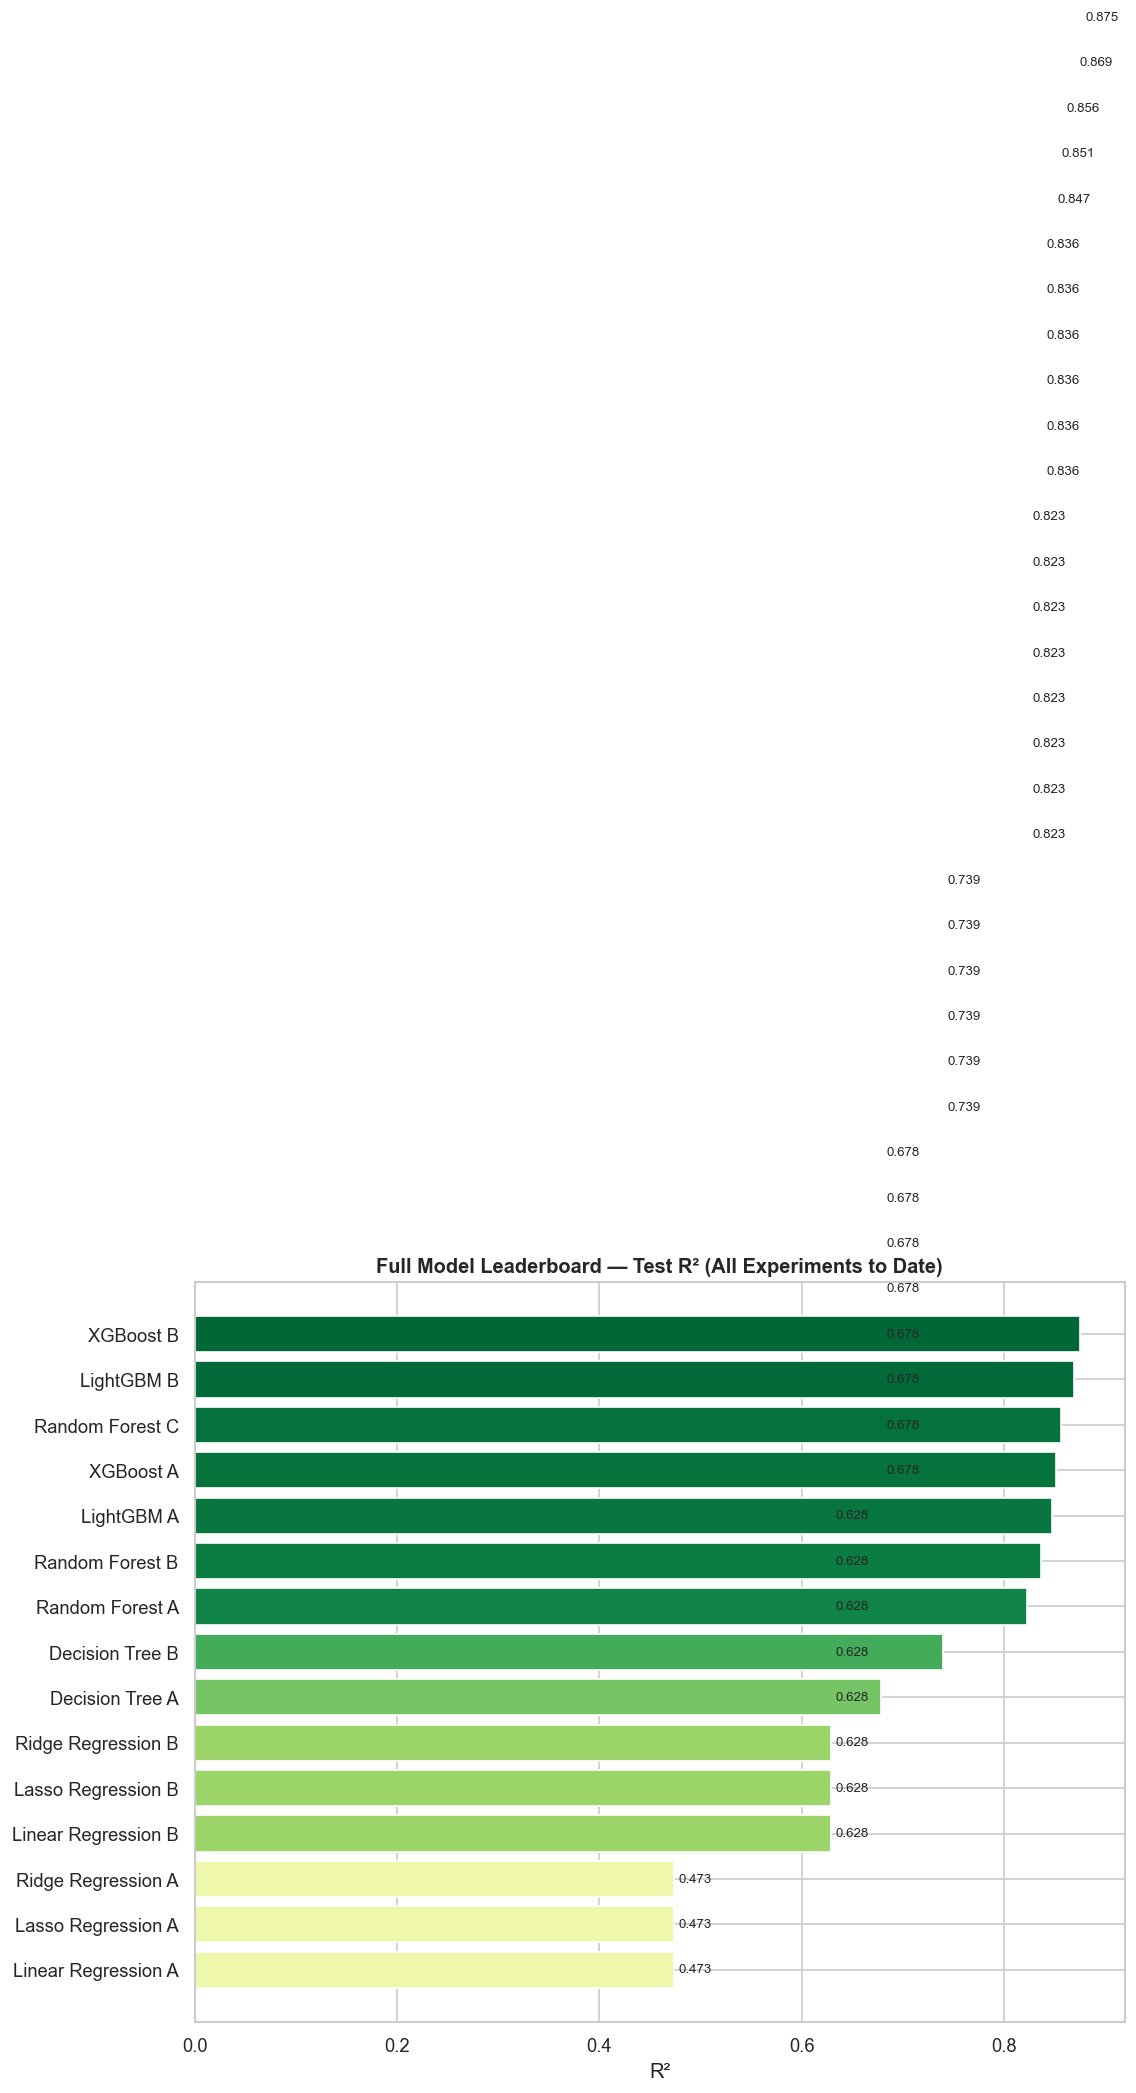

In [16]:
# Full leaderboard chart -- every model in the project, sorted by test R²
fig, ax = plt.subplots(figsize=(10, 8))
leaderboard = experiment_log.sort_values('r2_test', ascending=True)
colors = plt.cm.RdYlGn(leaderboard['r2_test'] / leaderboard['r2_test'].max())
ax.barh(leaderboard['experiment_id'], leaderboard['r2_test'], color=colors, edgecolor='white')
ax.set_title('Full Model Leaderboard — Test R² (All Experiments to Date)', fontweight='bold')
ax.set_xlabel('R²')
for i, v in enumerate(leaderboard['r2_test']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Summary & Next Steps

### Results — FINAL (School District Feature Included)

| Model | R² (test) | MAPE | MdAPE | MAE |
|---|---|---|---|---|
| Ridge Regression A | 0.4733 | 43.73% | 30.60% | $462,823 |
| Ridge Regression B | 0.6280 | 25.39% | 35.94% | $271,785 |
| Lasso Regression A | 0.4733 | 43.73% | 30.58% | $462,818 |
| Lasso Regression B | 0.7960 | 25.10% | 17.60% | $271,711 |
| Random Forest C (tuned) | 0.8722 | 13.23% | 8.50% | $177,712 |
| XGBoost A | 0.8510 | 16.59% | 11.87% | $211,024 |
| **XGBoost B** | **0.8894** | **12.85%** | **8.85%** | **$169,594** |
| LightGBM A | 0.8472 | 16.99% | 12.27% | $215,593 |
| LightGBM B | 0.8842 | 13.63% | 9.56% | $178,036 |

### Key Findings

**1. Regularization did almost nothing** — Ridge A/B and Lasso A/B landed within rounding
error of unregularized Linear Regression A/B, both before and after the school district
feature was added. Lasso zeroed only 1 of 25 features at `alpha=100`. Confirms the odd
coefficient signs in Linear Regression A were not a multicollinearity problem fixable by
regularization.

**2. XGBoost B is the best model in the project — 0.8894 test R², 8.85% MdAPE.** This now
includes the school district feature. It edges out Random Forest C (0.8722, tuned but on
the pre-school-district feature set) and Random Forest B (0.8644, final).

**3. Random Forest C's tuning was run on the pre-school-district snapshot** — it still
narrowly beats the final Random Forest B (0.8722 vs 0.8644), suggesting hyperparameter
tuning contributed more than the school district feature did. Re-tuning on the final
25-feature set would likely push Random Forest C slightly higher still — noted as a
follow-up, not done here to avoid re-running the ~3 minute search again.

**4. School district's contribution was small but real** — see
`05_feature_engineering.ipynb` for the full breakdown (+0.0004 to +0.0014 R² depending on
model type). `PostalCode_encoded` was already capturing most of the same signal.

**5. LightGBM tracked XGBoost closely but didn't beat it** on either tier — expected given
the algorithmic similarity between the two.

### Next Steps (Week 8)
- Move to `06_evaluation.ipynb` for the full metrics/insights write-up
- Consider re-tuning Random Forest C on the final 25-feature set (currently tuned on the
  pre-school-district snapshot)
- Consider a proper validation-month-based hyperparameter search for XGBoost B (the current
  best model), rather than reusing Random Forest C's subsample-search shortcut

### Deliverables
- `notebooks/05_advanced_models.ipynb` (this notebook)
- `deliverables/experiment_log.csv` — all experiments, final numbers including school district